# Fully Connected Autoencoder with SWaT 2020
# Split per file -> concatenate splits -> train/validation/test

In [5]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler

## Cargar archivos

In [6]:
clean_folder = "SWaT.A7_June 2020_clean"

file_paths = sorted(glob.glob(os.path.join(clean_folder, "*.csv")))

print("Archivos encontrados:")
for fp in file_paths:
    print(fp)

Archivos encontrados:
SWaT.A7_June 2020_clean\22June2020_1.csv
SWaT.A7_June 2020_clean\22June2020_2.csv
SWaT.A7_June 2020_clean\29June2020_1.csv
SWaT.A7_June 2020_clean\29June2020_2.csv


In [7]:
def load_clean_csv(path):
    df = pd.read_csv(path)
    
    # timestamp aparte
    timestamps = pd.to_datetime(df["t_stamp"], errors="coerce")
    df = df.drop(columns=["t_stamp"])
    
    # por seguridad: rellenar faltantes si aparecen
    df = df.ffill().bfill()
    
    return df, timestamps

In [8]:
dfs = []
timestamps_list = []

for fp in file_paths:
    df_i, ts_i = load_clean_csv(fp)
    dfs.append(df_i)
    timestamps_list.append(ts_i)

print("Número de archivos cargados:", len(dfs))
print("Shape archivo 1:", dfs[0].shape)

Número de archivos cargados: 4
Shape archivo 1: (14400, 60)


In [9]:
base_columns = dfs[0].columns.tolist()

for i, df_i in enumerate(dfs):
    assert df_i.columns.tolist() == base_columns, f"Columnas distintas en archivo {i}"

print("Todos los archivos tienen las mismas columnas.")
print("Número de variables:", len(base_columns))

Todos los archivos tienen las mismas columnas.
Número de variables: 60


## Función de split temporal por archivo (60/20/20)

In [10]:
def temporal_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    
    train_df = df.iloc[:train_end].copy()
    val_df   = df.iloc[train_end:val_end].copy()
    test_df  = df.iloc[val_end:].copy()
    
    return train_df, val_df, test_df

## Aplicar split a cada archivo y luego concatenar los splits

In [11]:
train_parts = []
val_parts = []
test_parts = []

for i, df_i in enumerate(dfs):
    train_i, val_i, test_i = temporal_split(df_i, train_ratio=0.6, val_ratio=0.2)
    
    train_parts.append(train_i)
    val_parts.append(val_i)
    test_parts.append(test_i)
    
    print(f"Archivo {i+1}:")
    print("  train:", train_i.shape)
    print("  val:  ", val_i.shape)
    print("  test: ", test_i.shape)

train_df = pd.concat(train_parts, axis=0, ignore_index=True)
val_df   = pd.concat(val_parts, axis=0, ignore_index=True)
test_df  = pd.concat(test_parts, axis=0, ignore_index=True)

print("\nShapes finales:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Archivo 1:
  train: (8640, 60)
  val:   (2880, 60)
  test:  (2880, 60)
Archivo 2:
  train: (2160, 60)
  val:   (720, 60)
  test:  (720, 60)
Archivo 3:
  train: (4320, 60)
  val:   (1440, 60)
  test:  (1441, 60)
Archivo 4:
  train: (4320, 60)
  val:   (1440, 60)
  test:  (1441, 60)

Shapes finales:
Train: (19440, 60)
Validation: (6480, 60)
Test: (6482, 60)


## Normalización

In [12]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df)
val_scaled   = scaler.transform(val_df)
test_scaled  = scaler.transform(test_df)

train_scaled = pd.DataFrame(train_scaled, columns=train_df.columns)
val_scaled   = pd.DataFrame(val_scaled, columns=val_df.columns)
test_scaled  = pd.DataFrame(test_scaled, columns=test_df.columns)

print(train_scaled.shape, val_scaled.shape, test_scaled.shape)

(19440, 60) (6480, 60) (6482, 60)


## Crear ventanas

In [13]:
def create_windows(data, window_size=60, stride=5):
    windows = []
    
    for i in range(0, len(data) - window_size, stride):
        window = data[i:i+window_size]
        windows.append(window)
    
    return np.array(windows)

In [14]:
L = 60
stride = 5

train_windows = create_windows(train_scaled.values, window_size=L, stride=stride)
val_windows   = create_windows(val_scaled.values, window_size=L, stride=stride)
test_windows  = create_windows(test_scaled.values, window_size=L, stride=stride)

print("Train windows:", train_windows.shape)
print("Validation windows:", val_windows.shape)
print("Test windows:", test_windows.shape)

Train windows: (3876, 60, 60)
Validation windows: (1284, 60, 60)
Test windows: (1285, 60, 60)


## Aplanar ventanas

In [15]:
n_train, L, n_features = train_windows.shape
X_train = train_windows.reshape(n_train, L * n_features)

n_val = val_windows.shape[0]
X_val = val_windows.reshape(n_val, L * n_features)

n_test = test_windows.shape[0]
X_test = test_windows.reshape(n_test, L * n_features)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (3876, 3600)
X_val: (1284, 3600)
X_test: (1285, 3600)


## Convertir a PyTorch

In [16]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

## Implementar modelo

In [17]:
class FCAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(FCAutoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

In [18]:
input_dim = X_train.shape[1]

model = FCAutoencoder(input_dim)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Dispositivo:", device)
print("Input dim:", input_dim)

Dispositivo: cpu
Input dim: 3600


## Entrenamiento

In [19]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 30
loss_history = []

In [20]:
for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for batch in train_loader:
        x = batch[0].to(device)
        
        optimizer.zero_grad()
        
        x_hat = model(x)
        loss = criterion(x_hat, x)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    epoch_loss = total_loss / len(train_loader)
    loss_history.append(epoch_loss)
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss}")

Epoch 1/30, Loss: 0.3062369063740871
Epoch 2/30, Loss: 0.14283184285779468
Epoch 3/30, Loss: 0.12647813891411805
Epoch 4/30, Loss: 0.11379419117555266
Epoch 5/30, Loss: 0.09745846102472211
Epoch 6/30, Loss: 0.08737415646309735
Epoch 7/30, Loss: 0.08492227315475218
Epoch 8/30, Loss: 0.07976711193313364
Epoch 9/30, Loss: 0.07886219755975438
Epoch 10/30, Loss: 0.07432007023179141
Epoch 11/30, Loss: 0.0748012317649898
Epoch 12/30, Loss: 0.08470589438544922
Epoch 13/30, Loss: 0.07180224323920051
Epoch 14/30, Loss: 0.08287698520561222
Epoch 15/30, Loss: 0.09167562764076913
Epoch 16/30, Loss: 0.08440569623327646
Epoch 17/30, Loss: 0.07686558236047382
Epoch 18/30, Loss: 0.06468768167446871
Epoch 19/30, Loss: 0.07318700804207169
Epoch 20/30, Loss: 0.0717862391325294
Epoch 21/30, Loss: 0.07850760128349066
Epoch 22/30, Loss: 0.06840322169734807
Epoch 23/30, Loss: 0.07458439895303035
Epoch 24/30, Loss: 0.0782077678891479
Epoch 25/30, Loss: 0.0699574948883936
Epoch 26/30, Loss: 0.05692484890889438


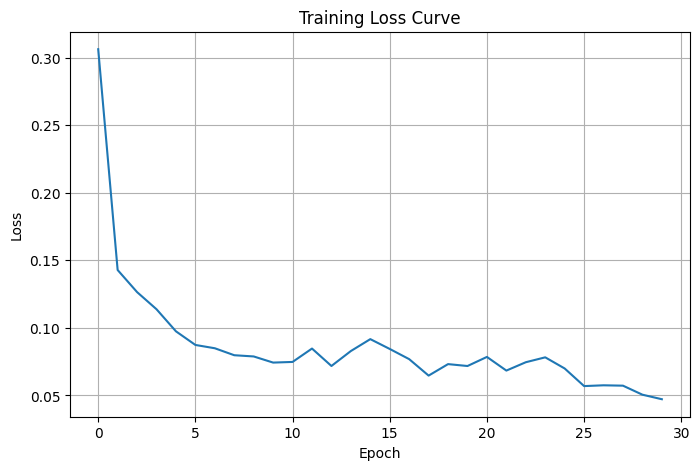

In [21]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

## Error de reconstrucción

### En validation

In [22]:
model.eval()

with torch.no_grad():
    x_val = X_val_tensor.to(device)
    x_val_hat = model(x_val)
    
    val_error = torch.mean((x_val - x_val_hat)**2, dim=1)
    val_reconstruction_errors = val_error.cpu().numpy()

### En test

In [23]:
with torch.no_grad():
    x_test = X_test_tensor.to(device)
    x_test_hat = model(x_test)
    
    test_error = torch.mean((x_test - x_test_hat)**2, dim=1)
    test_reconstruction_errors = test_error.cpu().numpy()

## Histograma de conjunto validation

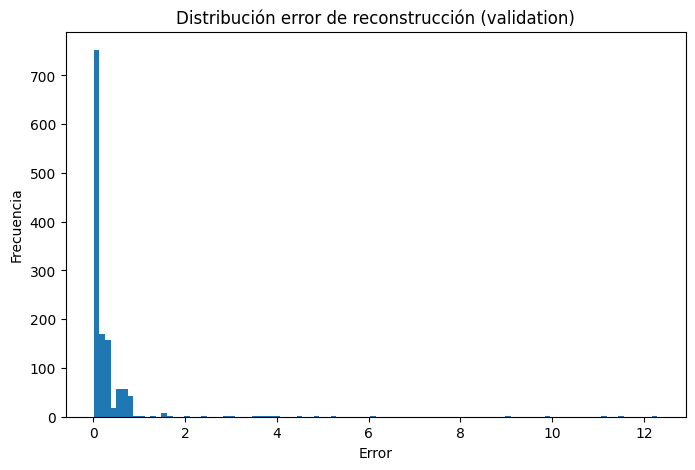

In [24]:
plt.figure(figsize=(8,5))
plt.hist(val_reconstruction_errors, bins=100)
plt.title("Distribución error de reconstrucción (validation)")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

## Percentiles de conjunto validation

In [25]:
percentiles = np.percentile(val_reconstruction_errors, [90, 95, 97.5, 99])
print("P90, P95, P97.5, P99 =", percentiles)

P90, P95, P97.5, P99 = [0.63051536 0.75933677 0.86160313 3.49555552]


## Definir umbrales desde validation

In [26]:
tau_95  = np.percentile(val_reconstruction_errors, 95)
tau_975 = np.percentile(val_reconstruction_errors, 97.5)
tau_99  = np.percentile(val_reconstruction_errors, 99)

print("tau_95 =", tau_95)
print("tau_97.5 =", tau_975)
print("tau_99 =", tau_99)

tau_95 = 0.75933677
tau_97.5 = 0.86160314
tau_99 = 3.4955556


## Calculo FAR sobre test

In [27]:
far_95  = np.mean(test_reconstruction_errors > tau_95)
far_975 = np.mean(test_reconstruction_errors > tau_975)
far_99  = np.mean(test_reconstruction_errors > tau_99)

print("FAR @ P95:", far_95, "->", far_95 * 100, "%")
print("FAR @ P97.5:", far_975, "->", far_975 * 100, "%")
print("FAR @ P99:", far_99, "->", far_99 * 100, "%")

FAR @ P95: 0.058365758754863814 -> 5.836575875486381 %
FAR @ P97.5: 0.05680933852140078 -> 5.680933852140078 %
FAR @ P99: 0.020233463035019456 -> 2.0233463035019454 %


## Comparación estadística Train vs Val

In [28]:
print("Val error mean:", np.mean(val_reconstruction_errors))
print("Test error mean:", np.mean(test_reconstruction_errors))

print("Val error median:", np.median(val_reconstruction_errors))
print("Test error median:", np.median(test_reconstruction_errors))

Val error mean: 0.2721416
Test error mean: 0.33321357
Val error median: 0.08134182
Test error median: 0.09984267


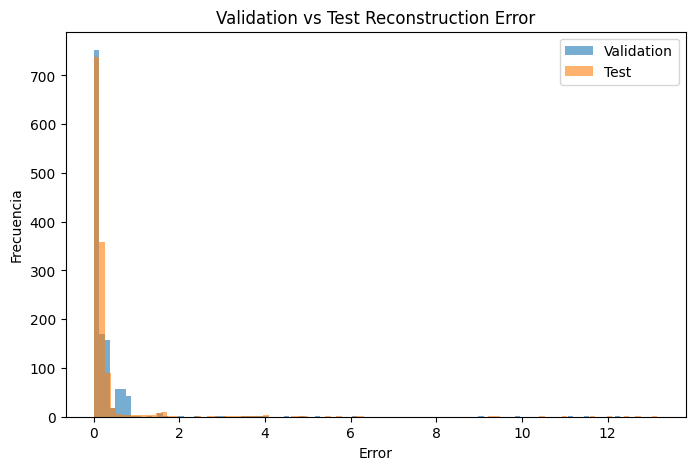

In [29]:
plt.figure(figsize=(8,5))
plt.hist(val_reconstruction_errors, bins=100, alpha=0.6, label="Validation")
plt.hist(test_reconstruction_errors, bins=100, alpha=0.6, label="Test")
plt.title("Validation vs Test Reconstruction Error")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()